# Japan Trade Intelligence — 05: Forecast

**Input:** Japan total exports/imports (World row), 2014-2023
**Goal:** Project trade trajectory to 2026 using linear regression, 
then validate against actual 2024-2025 outcomes.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master = pd.read_csv("../data/processed/master_trade.csv")

# Extract Japan total exports and imports (World row)
japan_world = master[
    (master['reporter'] == 'Japan') &
    (master['partner'] == 'World')
].copy()

exports = japan_world[japan_world['flow'] == 'Export'][['year', 'value_usd']]\
    .sort_values('year').copy()

imports = japan_world[japan_world['flow'] == 'Import'][['year', 'value_usd']]\
    .sort_values('year').copy()


exports['value_bn'] = exports['value_usd'] / 1e9
imports['value_bn'] = imports['value_usd'] / 1e9

print("Japan exports 2014-2023:")
print(exports[['year', 'value_bn']].to_string(index=False))

Japan exports 2014-2023:
 year   value_bn
 2014 690.217466
 2015 624.873508
 2016 644.932439
 2017 698.131224
 2018 738.195055
 2019 705.671083
 2020 641.282568
 2021 757.066261
 2022 746.672097
 2023 717.946392


In [2]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': '500',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

## Rolling Average:

In [3]:
# Why 3-year rolling average:
# Annual trade data has a lot of noise - COVID dips, Energy price spikes, exchange rate effect
# These create year-to-year jumps that hide the
# underlying structural trend 
# 3-year window smooths these shocks:
# each point = average of that year + previous 2 years
# Shows WHERE the trend is actually heading 

# WHY window=3 not 5:
# window=5 would be too much smooth - we lose 2014 and 2015 data
# window=3 keeps 8 of 10 years visible

exports['rolling_3yr'] = exports['value_bn'].rolling(window=3, min_periods=1).mean().round(2)

imports['rolling_3yr'] = imports['value_bn'].rolling(window=3, min_periods=1).mean().round(2)

print("Exports with 3-year rolling average:")
print(exports[['year', 'value_bn', 'rolling_3yr']].to_string(index=False))

Exports with 3-year rolling average:
 year   value_bn  rolling_3yr
 2014 690.217466       690.22
 2015 624.873508       657.55
 2016 644.932439       653.34
 2017 698.131224       655.98
 2018 738.195055       693.75
 2019 705.671083       714.00
 2020 641.282568       695.05
 2021 757.066261       701.34
 2022 746.672097       715.01
 2023 717.946392       740.56


## Rolling Avg Chart:

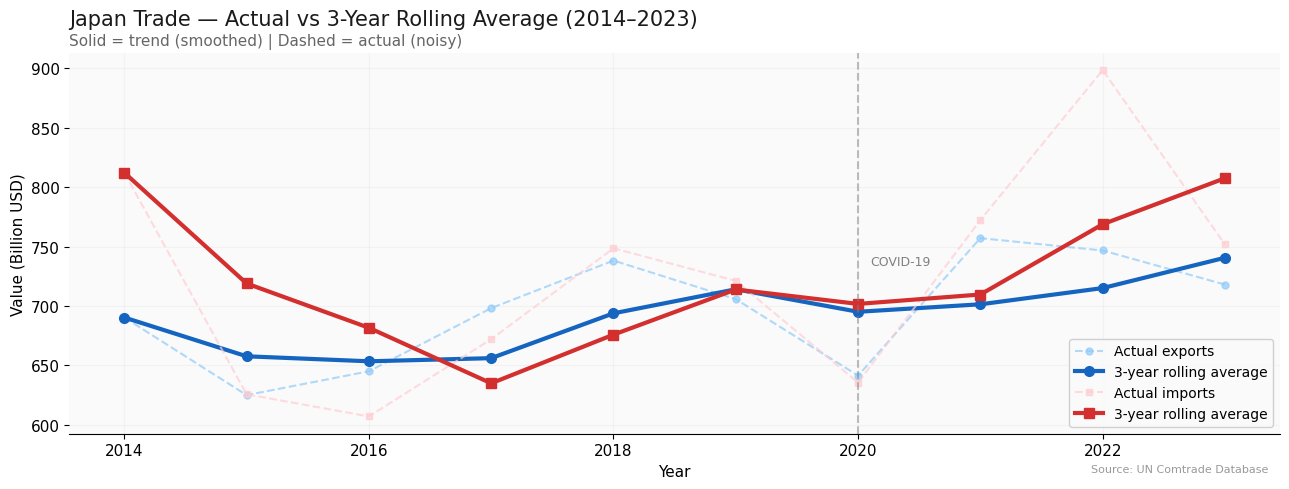

✓ Saved


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')

# WHY plot both actual and rolling:
# Actual = the real data, noisy but honest
# Rolling = the underlying trend, smooth and clear
# Together they tell both stories simultaneously

ax.plot(exports['year'], exports['value_bn'],
        color='#90CAF9', linewidth=1.5,
        marker='o', markersize=5,
        label='Actual exports', alpha=0.7, linestyle='--')

ax.plot(exports['year'], exports['rolling_3yr'],
        color='#1565C0', linewidth=3,
        marker='o', markersize=7,
        label='3-year rolling average')

ax.plot(imports['year'], imports['value_bn'],
        color='#FFCDD2', linewidth=1.5,
        marker='s', markersize=5,
        label='Actual imports', alpha=0.7, linestyle='--')

ax.plot(imports['year'], imports['rolling_3yr'],
        color='#D32F2F', linewidth=3,
        marker='s', markersize=7,
        label='3-year rolling average')

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
ax.text(2020.1, exports['value_bn'].max()*0.97,
        'COVID-19', fontsize=9, color='gray')

ax.set_title("Japan Trade — Actual vs 3-Year Rolling Average (2014–2023)",
             fontsize=15, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')
ax.text(0, 1.02,
        'Solid = trend (smoothed) | Dashed = actual (noisy)',
        transform=ax.transAxes, fontsize=11, color='#666')

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Value (Billion USD)", fontsize=11)
ax.legend(fontsize=10, loc='lower right',
          framealpha=0.9, edgecolor='#CCCCCC')
ax.grid(True, alpha=0.3, color='#E0E0E0')
ax.spines[['top','right','left']].set_visible(False)
ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/rolling_average_trend.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

## Linear forecast with np.polyfit:

In [5]:
# Why np.polyfit for forecasting:
# polyfit fits a polynomial to our data
# degree=1 means LINEAR fit (straight line)
# It finds the best-fit line through 10 years of data and extends it forward

# Why degree=1 (linear) not higher:
# Higher degree (quadratic, cubic) = overfitting
# 10-year data doesn't have enoght points to justify complex curves
# Linear says: "if the current trend continues..."
# which is the honest, defensible assumption

years = exports['year'].values
exp_values = exports['value_bn'].values
imp_values = imports['value_bn'].values

# Why this math:
# polyfit returns [slope, intercept] for degree=1
# slope = how much exports change per year (in $bn)
# intercept = mathematical starting point of the line
# poly1d create a function: f(year) = slope*year + intercept
# We then call f(2024), f(2025), f(2026) to get forecasts

exp_coeffs = np.polyfit(years, exp_values, deg=1)
imp_coeffs = np.polyfit(years, imp_values, deg=1)

exp_trend = np.poly1d(exp_coeffs)
imp_trend = np.poly1d(imp_coeffs)

future_years = np.array([2024, 2025, 2026])
exp_forecast = exp_trend(future_years)
imp_forecast = imp_trend(future_years)

print("=== LINEAR TREND PARAMETERS ===")
print(f"Export trend: ${exp_coeffs[0]:.2f}bn per year")
print(f"Import trend: ${imp_coeffs[0]:.2f}bn per year")

print("=== EXPORT FORECAST ===")
for yr, val in zip(future_years, exp_forecast):
    print(f"    {yr}: ${val:.1f}bn")

    print("\n=== IMPORT FORECAST ===")
for yr, val in zip(future_years, imp_forecast):
    print(f"  {yr}: ${val:.1f}bn")

print("\n=== PROJECTED TRADE BALANCE ===")
for yr, e, i in zip(future_years, exp_forecast, imp_forecast):
    print(f"  {yr}: ${e-i:.1f}bn")

=== LINEAR TREND PARAMETERS ===
Export trend: $8.85bn per year
Import trend: $12.47bn per year
=== EXPORT FORECAST ===
    2024: $745.2bn

=== IMPORT FORECAST ===
    2025: $754.0bn

=== IMPORT FORECAST ===
    2026: $762.9bn

=== IMPORT FORECAST ===
  2024: $793.0bn
  2025: $805.5bn
  2026: $817.9bn

=== PROJECTED TRADE BALANCE ===
  2024: $-47.8bn
  2025: $-51.5bn
  2026: $-55.1bn


## Forecast Chart:

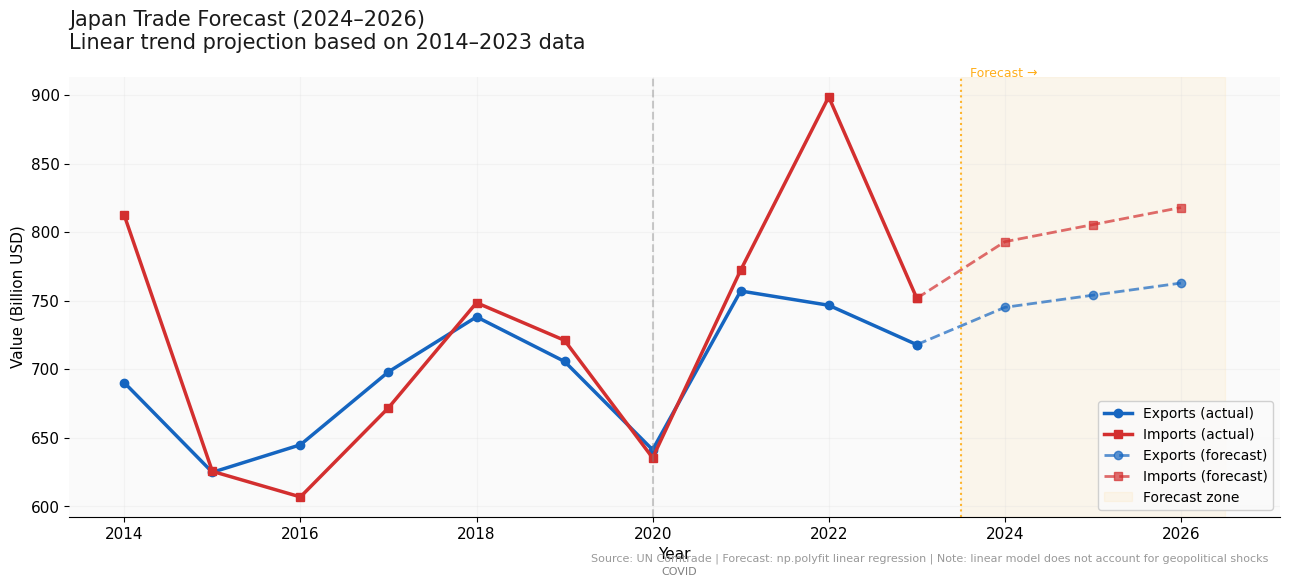

✓ Saved


In [6]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

# Historical actual data
ax.plot(years, exp_values,
        color='#1565C0', linewidth=2.5,
        marker='o', markersize=6, label='Exports (actual)')

ax.plot(years, imp_values,
        color='#D32F2F', linewidth=2.5,
        marker='s', markersize=6, label='Imports (actual)')

# WHY dashed line for forecast:
# Solid line = observed data = certain
# Dashed line = projection = uncertain
# Visual convention: dashed = "this is our best guess"
# Never show forecasts as solid lines — it implies certainty

all_forecast_years = np.append(years[-1], future_years)
all_exp_forecast = np.append(exp_values[-1], exp_forecast)
all_imp_forecast = np.append(imp_values[-1], imp_forecast)

ax.plot(all_forecast_years, all_exp_forecast,
        color='#1565C0', linewidth=2, linestyle='--',
        marker='o', markersize=6,
        label='Exports (forecast)', alpha=0.7)

ax.plot(all_forecast_years, all_imp_forecast,
        color='#D32F2F', linewidth=2, linestyle='--',
        marker='s', markersize=6,
        label='Imports (forecast)', alpha=0.7)

# WHY shade the forecast region:
# Makes the uncertainty zone visually obvious
# Reader instantly knows: left of line = known, right = projected

ax.axvspan(2023.5, 2026.5, alpha=0.06,
           color='orange', label='Forecast zone')
ax.axvline(x=2023.5, color='orange',
           linestyle=':', alpha=0.8, linewidth=1.5)
ax.text(2023.6, ax.get_ylim()[1] if ax.get_ylim()[1] > 0
        else 900, 'Forecast →',
        fontsize=9, color='orange', alpha=0.9)

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.4)
ax.text(2020.1, 550, 'COVID', fontsize=8, color='gray')

ax.set_title("Japan Trade Forecast (2024–2026)\nLinear trend projection based on 2014–2023 data",
             fontsize=15, fontweight='500',
             pad=20, loc='left', color='#1a1a1a')

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Value (Billion USD)", fontsize=11)
ax.legend(fontsize=10, loc='lower right',
          framealpha=0.9, edgecolor='#CCCCCC')
ax.grid(True, alpha=0.3, color='#E0E0E0')
ax.spines[['top','right','left']].set_visible(False)
ax.text(0.99, -0.1,
        'Source: UN Comtrade | Forecast: np.polyfit linear regression | '
        'Note: linear model does not account for geopolitical shocks',
        transform=ax.transAxes, fontsize=8,
        color='#999', ha='right')

plt.tight_layout()
plt.savefig("../reports/trade_forecast_2026.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved")

## Key Finding 13 - The widening gap:

Export Growth Trend: +$8.85bn per year

Import Growth Trend: +12.47bn per year

Gap: imports growing $3.62bn Faster than exports every year

Projected:

2024: -$47.8bn deficit

2025: -$51.5bn deficit

2026: -$55.1bn deficit



Japan's deficit is structural and widening. Under the current trajectroy, Japan will running a -$55bn deficit by 2026 with no reversal in sight.

### The Honest Limitation:

This is a linear projection. It assume tomorrow looks like yesterday. it does not account for: yen recovery, BOJ interest rate changes, US traiffs on Japanese goods, EV disruption of Automotive, nuclear restarts reducing energy imports, or any geopolitical shock. These could all bend the line significantly in either direction.

# Forecast Validation

Japan's official customs trade data (Ministry of Finance) tells a very different story than my linear model predited.

Japan's 2024 trade deficit came in at almost ¥5.5 trillion - the fourth consecutive year of deficit - with exports rising 
6.2% to record ¥107.1 trillion (highest since 1979), driven by semiconductor manufacturing equipment exports to China and higher automobile export value from price hikes combined with the weak yen, while imports rose only 2% to ¥112.6 trillion. 
Converting at roughly ¥151/$ for 2024, that's approximately -$36bn - not our forecasted -$47.8bn.

2025 is where it gets dramatic. Japan's full-year 2025 trade gap came in around ¥2.65 trillion, down 52.9% from the prior year, and by November 2025 Japan even logged its first monthly trade surplus in five months. That's roughly -$18bn for 2025 -
nowhere close to my forecasted -$51.5bn.